<a href="https://colab.research.google.com/github/Hgrcrls/o3source_location/blob/main/ozone_source_localization_v2/notebooks/02_generate_augmented_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Configuração do Ambiente
Ambiente detectado: Google Colab
Mounted at /content/drive
Pasta processed: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data/processed
Pasta augm: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data/augm

Verificação da pasta de saída
Pasta: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data/augm
Arquivos encontrados: 1088
Deseja apagar os arquivos antigos? (s/n): s
Pasta limpa
Arquivos encontrados: 17


Interpolando campos: 100%|██████████| 17/17 [00:01<00:00, 10.92it/s]



Total de pares: 136
Total de campos sintéticos: 544


Gerando campos: 100%|██████████| 544/544 [00:10<00:00, 50.71it/s]


Campos base: 544


Aplicando augmentation: 100%|██████████| 544/544 [00:21<00:00, 25.73it/s]


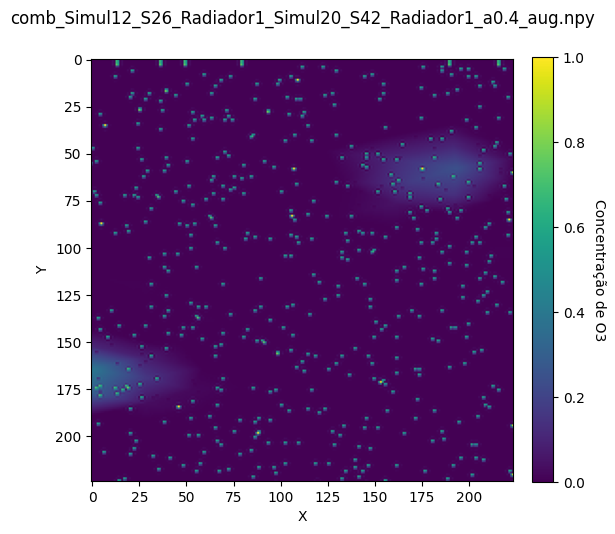


Pipeline finalizado com sucesso


In [2]:
# =========================================================
# Pipeline de geração de dataset sintético de concentração de ozônio
# =========================================================

import os
import sys
import shutil
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, shift
from skimage.transform import resize

# =========================================================
# Constantes
# =========================================================

GRID_SIZE = 224
ALPHAS = [0.2, 0.4, 0.6, 0.8]

GAUSSIAN_STD = 0.02
SALT_PEPPER_PROB = 0.01
BLUR_SIGMA = 1.5
MAX_SHIFT = 5
DOWNSAMPLE_FACTOR = 2

# =========================================================
# Detectar ambiente
# =========================================================

def is_colab():
    return "google.colab" in sys.modules

# =========================================================
# Configuração do ambiente
# =========================================================

def configure_environment():

    print("\n==============================")
    print("Configuração do Ambiente")
    print("==============================")

    if is_colab():

        print("Ambiente detectado: Google Colab")

        from google.colab import drive
        drive.mount("/content/drive", force_remount=True)

        base_path = "/content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data"

    else:

        print("Ambiente detectado: Execução local")

        base_path = "./sim/sim"

    if not os.path.exists(base_path):
        raise Exception(f"Caminho não encontrado: {base_path}")

    processed_path = os.path.join(base_path, "processed")
    augm_path = os.path.join(base_path, "augm")

    os.makedirs(augm_path, exist_ok=True)

    print("Pasta processed:", processed_path)
    print("Pasta augm:", augm_path)

    return processed_path, augm_path

# =========================================================
# Limpar pasta augm
# =========================================================

def ask_clean_directory(path):

    print("\n==============================")
    print("Verificação da pasta de saída")
    print("==============================")

    files = os.listdir(path)

    print("Pasta:", path)
    print("Arquivos encontrados:", len(files))

    if len(files) == 0:
        print("Pasta já está vazia")
        return

    answer = input("Deseja apagar os arquivos antigos? (s/n): ").lower()

    if answer == "s":

        for file in files:

            file_path = os.path.join(path, file)

            if os.path.isfile(file_path):
                os.remove(file_path)
            else:
                shutil.rmtree(file_path)

        print("Pasta limpa")

# =========================================================
# Carregar arquivos processados
# =========================================================

def list_processed_files(path):

    if not os.path.exists(path):
        raise FileNotFoundError("Pasta processed não encontrada")

    files = sorted([f for f in os.listdir(path) if f.endswith(".csv")])

    print("Arquivos encontrados:", len(files))

    return files


def load_simulations(files, path):

    data = []
    names = []

    for f in files:

        df = pd.read_csv(os.path.join(path, f))

        data.append(df)
        names.append(f)

    return data, names

# =========================================================
# Interpolação
# =========================================================

def interpolate_field(df, size=GRID_SIZE):

    x = df["x"].values
    y = df["y"].values
    z = df["value"].values

    xi = np.linspace(x.min(), x.max(), size)
    yi = np.linspace(y.min(), y.max(), size)

    xi, yi = np.meshgrid(xi, yi)

    zi = griddata((x, y), z, (xi, yi), method="linear")

    return np.nan_to_num(zi, nan=0.0)


def convert_all_fields(data):

    grids = []

    for df in tqdm(data, desc="Interpolando campos"):

        grid = interpolate_field(df)

        grids.append(grid)

    return grids

# =========================================================
# Combinações lineares
# =========================================================

def combine_fields(field1, field2, alpha):

    return alpha * field1 + (1 - alpha) * field2


def generate_combinations(grids, names, output_path):

    pairs = list(combinations(range(len(grids)), 2))

    total = len(pairs) * len(ALPHAS)

    print("\nTotal de pares:", len(pairs))
    print("Total de campos sintéticos:", total)

    with tqdm(total=total, desc="Gerando campos") as pbar:

        for i, j in pairs:

            for alpha in ALPHAS:

                field = combine_fields(grids[i], grids[j], alpha)

                name1 = names[i].replace(".csv","")
                name2 = names[j].replace(".csv","")

                filename = f"comb_{name1}_{name2}_a{alpha:.1f}.npy"

                np.save(os.path.join(output_path, filename), field)

                pbar.update(1)

# =========================================================
# Data augmentation
# =========================================================

def add_gaussian_noise(field):

    noise = np.random.normal(0, GAUSSIAN_STD, field.shape)

    return np.clip(field + noise, 0, 1)


def add_salt_pepper(field):

    noisy = field.copy()

    salt = np.random.rand(*field.shape) < SALT_PEPPER_PROB
    pepper = np.random.rand(*field.shape) < SALT_PEPPER_PROB

    noisy[salt] = 1
    noisy[pepper] = 0

    return noisy


def blur_field(field):

    return gaussian_filter(field, sigma=BLUR_SIGMA)


def random_shift(field):

    dx = np.random.uniform(-MAX_SHIFT, MAX_SHIFT)
    dy = np.random.uniform(-MAX_SHIFT, MAX_SHIFT)

    return shift(field, (dx, dy), mode="nearest")


def downsample(field):

    small = resize(
        field,
        (field.shape[0] // DOWNSAMPLE_FACTOR, field.shape[1] // DOWNSAMPLE_FACTOR),
        anti_aliasing=True
    )

    return resize(small, field.shape, anti_aliasing=True)


def augment_field(field):

    aug = field.copy()

    if np.random.rand() < 0.5:
        aug = add_gaussian_noise(aug)

    if np.random.rand() < 0.3:
        aug = add_salt_pepper(aug)

    if np.random.rand() < 0.4:
        aug = blur_field(aug)

    if np.random.rand() < 0.4:
        aug = random_shift(aug)

    if np.random.rand() < 0.3:
        aug = downsample(aug)

    return np.clip(aug, 0, 1)


def apply_augmentation(path):

    files = [f for f in os.listdir(path) if f.endswith(".npy")]

    print("Campos base:", len(files))

    for file in tqdm(files, desc="Aplicando augmentation"):

        field = np.load(os.path.join(path, file))

        augmented = augment_field(field)

        new_name = file.replace(".npy", "_aug.npy")

        np.save(os.path.join(path, new_name), augmented)

# =========================================================
# Visualização corrigida
# =========================================================

def visualize_random_field(path):

    files = [f for f in os.listdir(path) if f.endswith(".npy")]

    if len(files) == 0:
        print("Nenhum campo encontrado")
        return

    file = np.random.choice(files)

    field = np.load(os.path.join(path, file))

    plt.figure(figsize=(6,6))

    im = plt.imshow(field, cmap="viridis")

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Concentração de O3", rotation=270, labelpad=15)

    plt.title(file, fontsize=12, pad=25)

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.tight_layout()

    plt.show()

# =========================================================
# MAIN
# =========================================================

def main():

    processed_path, augm_path = configure_environment()

    ask_clean_directory(augm_path)

    files = list_processed_files(processed_path)

    data, names = load_simulations(files, processed_path)

    grids = convert_all_fields(data)

    generate_combinations(grids, names, augm_path)

    apply_augmentation(augm_path)

    visualize_random_field(augm_path)

    print("\nPipeline finalizado com sucesso")

# =========================================================
# Execução
# =========================================================

if __name__ == "__main__":
    main()